In [1]:
!pip install pandas numpy matplotlib seaborn mlxtend joblib


[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: C:\Users\Gunjan\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import os
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from mlxtend.frequent_patterns import fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

In [3]:
df = pd.read_csv('../data/clustered_data.csv')

print(f' Loaded dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'\n Available columns:')
print(list(df.columns))
df.head()

 Loaded dataset: 101,766 rows × 45 columns

 Available columns:
['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted_30', 'cluster']


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,num_lab_procedures,num_procedures,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted_30,cluster
0,2,0,0,6,25,1,1,7,41,0,...,1,1,0,0,0,0,1,0,0,2
1,2,0,1,1,1,7,3,7,59,0,...,3,1,0,0,0,0,0,1,0,2
2,0,0,2,1,1,7,2,7,11,5,...,1,1,0,0,0,0,1,1,0,2
3,2,1,3,1,1,7,2,7,44,1,...,3,1,0,0,0,0,0,1,0,2
4,2,1,4,1,1,7,1,7,51,0,...,2,1,0,0,0,0,0,1,0,2


In [4]:
medication_cols = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'glipizide', 'glyburide', 'pioglitazone',
    'rosiglitazone', 'acarbose', 'insulin', 'glyburide-metformin'
]

# Keep only medication columns that exist in our dataset
medication_cols = [c for c in medication_cols if c in df.columns]
print(f' Medication columns found ({len(medication_cols)}): {medication_cols}')

# These columns have values like: 'No', 'Steady', 'Up', 'Down'
# Convert to binary: 1 = prescribed (any value except 'No'), 0 = not prescribed
df_meds = df[medication_cols].copy()
for col in medication_cols:
    df_meds[col] = df_meds[col].apply(lambda x: 0 if str(x) in ['No', '0', 0] else 1)

print('\n Medication columns converted to binary (0/1)')
df_meds.head()

 Medication columns found (12): ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'insulin', 'glyburide-metformin']

 Medication columns converted to binary (0/1)


,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,glipizide,glyburide,pioglitazone,rosiglitazone,acarbose,insulin,glyburide-metformin
0,1,1,1,1,1,1,1,1,1,1,1,1
1,1,1,1,1,1,1,1,1,1,1,1,1
2,1,1,1,1,1,1,1,1,1,1,1,1
3,1,1,1,1,1,1,1,1,1,1,1,1
4,1,1,1,1,1,1,1,1,1,1,1,1


In [5]:
df_features = pd.DataFrame(index=df.index)

# Age group
if 'age' in df.columns:
    age_median = df['age'].median()
    df_features['elderly_patient']    = (df['age'] > age_median).astype(int)
    df_features['young_patient']      = (df['age'] <= age_median).astype(int)

# High medication count
if 'num_medications' in df.columns:
    med_thresh = df['num_medications'].quantile(0.75)
    df_features['high_medication_count'] = (df['num_medications'] >= med_thresh).astype(int)

# Multiple diagnoses
if 'number_diagnoses' in df.columns:
    df_features['multiple_diagnoses'] = (df['number_diagnoses'] >= 5).astype(int)

# Prior inpatient visits
if 'number_inpatient' in df.columns:
    df_features['prior_inpatient_visits'] = (df['number_inpatient'] >= 1).astype(int)

# Emergency visits
if 'number_emergency' in df.columns:
    df_features['emergency_visits'] = (df['number_emergency'] >= 1).astype(int)

# Long hospital stay
if 'time_in_hospital' in df.columns:
    df_features['long_stay'] = (df['time_in_hospital'] >= 7).astype(int)

# Diagnosis categories (if mapped in Notebook 1)
if 'diag_1' in df.columns:
    # diag_1 was label-encoded in Notebook 1 — create binary flags per category
    # Get unique values and create one binary column per category
    for val in df['diag_1'].unique():
        col_name = f'diag_{val}'
        df_features[col_name] = (df['diag_1'] == val).astype(int)

# Readmission target as an item (this is the consequent we look for)
df_features['readmitted_30d'] = df['readmitted_30'].astype(int)

print(f' Derived features created ({len(df_features.columns)}):')
print(list(df_features.columns))

 Derived features created (17):
['elderly_patient', 'young_patient', 'high_medication_count', 'multiple_diagnoses', 'prior_inpatient_visits', 'emergency_visits', 'long_stay', 'diag_7', 'diag_6', 'diag_0', 'diag_8', 'diag_4', 'diag_5', 'diag_2', 'diag_3', 'diag_1', 'readmitted_30d']


In [6]:
df_transactions = pd.concat([df_meds, df_features], axis=1)

# Convert all to boolean (required by mlxtend apriori)
df_transactions = df_transactions.astype(bool)

print(f' Transaction dataset ready: {df_transactions.shape[0]:,} patients × {df_transactions.shape[1]} items')
print(f'\n Item frequency (% of patients with each item):')
item_freq = df_transactions.mean().sort_values(ascending=False).round(3) * 100
print(item_freq.to_string())

 Transaction dataset ready: 101,766 patients × 29 items

 Item frequency (% of patients with each item):
chlorpropamide            100.0
acarbose                  100.0
glyburide-metformin       100.0
nateglinide               100.0
repaglinide               100.0
rosiglitazone              99.9
pioglitazone               99.9
glimepiride                99.8
glipizide                  99.4
glyburide                  99.4
metformin                  99.4
multiple_diagnoses         90.6
insulin                    88.0
young_patient              54.7
elderly_patient            45.3
prior_inpatient_visits     33.5
diag_0                     29.9
high_medication_count      27.1
diag_7                     26.2
long_stay                  20.8
diag_8                     14.2
emergency_visits           11.2
readmitted_30d             11.2
diag_2                      9.3
diag_4                      6.9
diag_3                      5.0
diag_5                      4.9
diag_6                      3.4

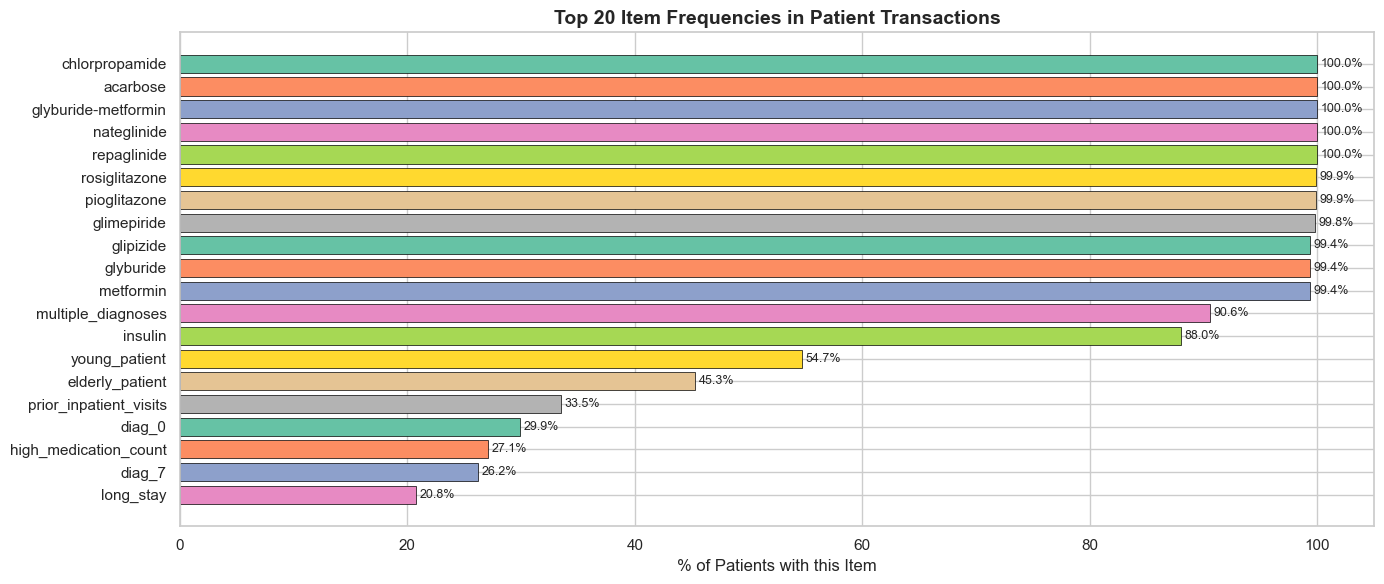

 Saved: ../outputImg/chart41_item_frequency.png


In [7]:
top_items = item_freq.head(20)

fig, ax = plt.subplots(figsize=(14, 6))
colors = sns.color_palette('Set2', len(top_items))
bars = ax.barh(top_items.index[::-1], top_items.values[::-1],
               color=colors[::-1], edgecolor='black', linewidth=0.5)
ax.set_title('Top 20 Item Frequencies in Patient Transactions',
             fontsize=14, fontweight='bold')
ax.set_xlabel('% of Patients with this Item')
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.3, bar.get_y() + bar.get_height()/2,
            f'{w:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputImg/chart41_item_frequency.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: ../outputImg/chart41_item_frequency.png')

In [8]:
MIN_SUPPORT    = 0.08   # appears in at least 5% of patients
MIN_CONFIDENCE = 0.13   # rule is correct at least 55% of the time
MIN_LIFT       = 1.3   # rule is 1.2x better than random chance

print(f'⛏️  Running Fpgrowth Algorithm...')
print(f'   Min Support:    {MIN_SUPPORT} ({MIN_SUPPORT*100:.0f}% of patients)')
print(f'   Min Confidence: {MIN_CONFIDENCE}')
print(f'   Min Lift:       {MIN_LIFT}\n')

# Step 1: Find frequent itemsets
frequent_itemsets = fpgrowth(
    df_transactions,
    min_support=MIN_SUPPORT,
    use_colnames=True,
    max_len=4        # max 4 items per rule antecedent
)

print(f' Frequent itemsets found: {len(frequent_itemsets):,}')
print(f'\nItemset size distribution:')
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)
print(frequent_itemsets['length'].value_counts().sort_index().to_string())

⛏️  Running Fpgrowth Algorithm...
   Min Support:    0.08 (8% of patients)
   Min Confidence: 0.13
   Min Lift:       1.3

 Frequent itemsets found: 6,680

Itemset size distribution:
length
1      24
2     237
3    1349
4    5070


In [9]:
rules = association_rules(
    frequent_itemsets,
    metric='lift',
    min_threshold=1.0 
)


# Sort by lift descending
rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)

print(f' Total association rules generated: {len(rules):,}')
print(f'\n Rules columns: {list(rules.columns)}')
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

 Total association rules generated: 36,150

 Rules columns: ['antecedents', 'consequents', 'antecedent support', 'consequent support', 'support', 'confidence', 'lift', 'representativity', 'leverage', 'conviction', 'zhangs_metric', 'jaccard', 'certainty', 'kulczynski']


,antecedents,consequents,support,confidence,lift
0,"(multiple_diagnoses, high_medication_count)","(glyburide-metformin, long_stay)",0.111914,0.432943,2.083556
1,"(glyburide-metformin, long_stay)","(multiple_diagnoses, high_medication_count)",0.111914,0.538589,2.083556
2,"(multiple_diagnoses, high_medication_count, ac...",(long_stay),0.111914,0.432992,2.083498
3,(long_stay),"(multiple_diagnoses, high_medication_count, ac...",0.111914,0.538512,2.083498
4,"(multiple_diagnoses, high_medication_count)","(repaglinide, long_stay)",0.111815,0.432563,2.083402
5,"(repaglinide, long_stay)","(multiple_diagnoses, high_medication_count)",0.111815,0.538549,2.083402
6,(long_stay),"(multiple_diagnoses, nateglinide, high_medicat...",0.111884,0.538371,2.083266
7,"(multiple_diagnoses, nateglinide, high_medicat...",(long_stay),0.111884,0.432944,2.083266
8,(long_stay),"(multiple_diagnoses, high_medication_count)",0.111914,0.538512,2.083261
9,(long_stay),"(glyburide-metformin, multiple_diagnoses, high...",0.111914,0.538512,2.083261


In [10]:
readmit_rules = rules[
    rules['consequents'].apply(lambda x: 'readmitted_30d' in x)
].copy().reset_index(drop=True)

# Also get rules where readmission is in antecedent (for exploration)
readmit_antecedent_rules = rules[
    rules['antecedents'].apply(lambda x: 'readmitted_30d' in x)
].copy().reset_index(drop=True)

print(f' Rules predicting readmission (readmitted_30d as consequent): {len(readmit_rules)}')
print(f' Rules with readmission as antecedent: {len(readmit_antecedent_rules)}')

print(f'\n Top 15 Rules Predicting Readmission (sorted by Lift):')
display_cols = ['antecedents', 'consequents', 'support', 'confidence', 'lift', 'leverage']
display_cols = [c for c in display_cols if c in readmit_rules.columns]

readmit_rules[display_cols].head(15).style\
    .format({'support': '{:.3f}', 'confidence': '{:.3f}',
             'lift': '{:.3f}', 'leverage': '{:.4f}'})\
    .background_gradient(subset=['lift'], cmap='YlOrRd')

 Rules predicting readmission (readmitted_30d as consequent): 1001
 Rules with readmission as antecedent: 1001

 Top 15 Rules Predicting Readmission (sorted by Lift):


,antecedents,consequents,support,confidence,lift,leverage
0,"frozenset({'glyburide', 'multiple_diagnoses'})","frozenset({'insulin', 'readmitted_30d'})",0.088,0.098,1.034,0.0029
1,"frozenset({'glyburide', 'multiple_diagnoses'})","frozenset({'metformin', 'readmitted_30d'})",0.103,0.115,1.034,0.0034
2,"frozenset({'glyburide', 'multiple_diagnoses', 'rosiglitazone'})",frozenset({'readmitted_30d'}),0.104,0.115,1.034,0.0034
3,"frozenset({'multiple_diagnoses', 'rosiglitazone'})","frozenset({'insulin', 'readmitted_30d'})",0.089,0.098,1.034,0.0029
4,"frozenset({'repaglinide', 'glyburide', 'multiple_diagnoses'})",frozenset({'readmitted_30d'}),0.104,0.115,1.034,0.0034
5,"frozenset({'glyburide', 'multiple_diagnoses'})","frozenset({'glyburide-metformin', 'readmitted_30d'})",0.104,0.115,1.033,0.0034
6,"frozenset({'repaglinide', 'multiple_diagnoses'})","frozenset({'insulin', 'readmitted_30d'})",0.089,0.098,1.033,0.0029
7,"frozenset({'glyburide', 'multiple_diagnoses', 'glyburide-metformin'})",frozenset({'readmitted_30d'}),0.104,0.115,1.033,0.0034
8,"frozenset({'glyburide', 'multiple_diagnoses', 'nateglinide'})",frozenset({'readmitted_30d'}),0.104,0.115,1.033,0.0034
9,"frozenset({'glyburide', 'multiple_diagnoses', 'chlorpropamide'})",frozenset({'readmitted_30d'}),0.104,0.115,1.033,0.0034


In [11]:
# Check how many rules contain readmitted_30d at all
all_readmit_rules = rules[
    rules['consequents'].apply(lambda x: 'readmitted_30d' in x) |
    rules['antecedents'].apply(lambda x: 'readmitted_30d' in x)
]
print(f"Total rules mentioning readmitted_30d: {len(all_readmit_rules)}")

# Check max confidence for rules where it IS the consequent (before filtering)
readmit_consequent = rules[rules['consequents'].apply(lambda x: 'readmitted_30d' in x)]
print(f"Rules with it as consequent: {len(readmit_consequent)}")

# What confidence values exist for these?
if len(readmit_consequent) > 0:
    print(readmit_consequent['confidence'].describe())

Total rules mentioning readmitted_30d: 2002
Rules with it as consequent: 1001
count    1001.000000
mean        0.109890
std         0.005788
min         0.088803
25%         0.110790
50%         0.111563
75%         0.111743
max         0.115366
Name: confidence, dtype: float64


In [12]:
print('\n' + '=' * 70)
print(' TOP RULES IN PLAIN ENGLISH (Predicting Readmission)')
print('=' * 70)

for i, row in readmit_rules.head(15).iterrows():
    antecedents = ', '.join(list(row['antecedents']))
    consequents = ', '.join(list(row['consequents']))
    print(f'\nRule {i+1}:')
    print(f'  IF   patient has: [{antecedents}]')
    print(f'  THEN likely:      [{consequents}]')
    print(f'  Support:    {row["support"]:.3f} ({row["support"]*100:.1f}% of all patients)')
    print(f'  Confidence: {row["confidence"]:.3f} ({row["confidence"]*100:.1f}% of the time this is true)')
    print(f'  Lift:       {row["lift"]:.3f} ({row["lift"]:.1f}x better than random chance)')


 TOP RULES IN PLAIN ENGLISH (Predicting Readmission)

Rule 1:
  IF   patient has: [glyburide, multiple_diagnoses]
  THEN likely:      [insulin, readmitted_30d]
  Support:    0.088 (8.8% of all patients)
  Confidence: 0.098 (9.8% of the time this is true)
  Lift:       1.034 (1.0x better than random chance)

Rule 2:
  IF   patient has: [glyburide, multiple_diagnoses]
  THEN likely:      [metformin, readmitted_30d]
  Support:    0.103 (10.3% of all patients)
  Confidence: 0.115 (11.5% of the time this is true)
  Lift:       1.034 (1.0x better than random chance)

Rule 3:
  IF   patient has: [glyburide, multiple_diagnoses, rosiglitazone]
  THEN likely:      [readmitted_30d]
  Support:    0.104 (10.4% of all patients)
  Confidence: 0.115 (11.5% of the time this is true)
  Lift:       1.034 (1.0x better than random chance)

Rule 4:
  IF   patient has: [multiple_diagnoses, rosiglitazone]
  THEN likely:      [insulin, readmitted_30d]
  Support:    0.089 (8.9% of all patients)
  Confidence: 0

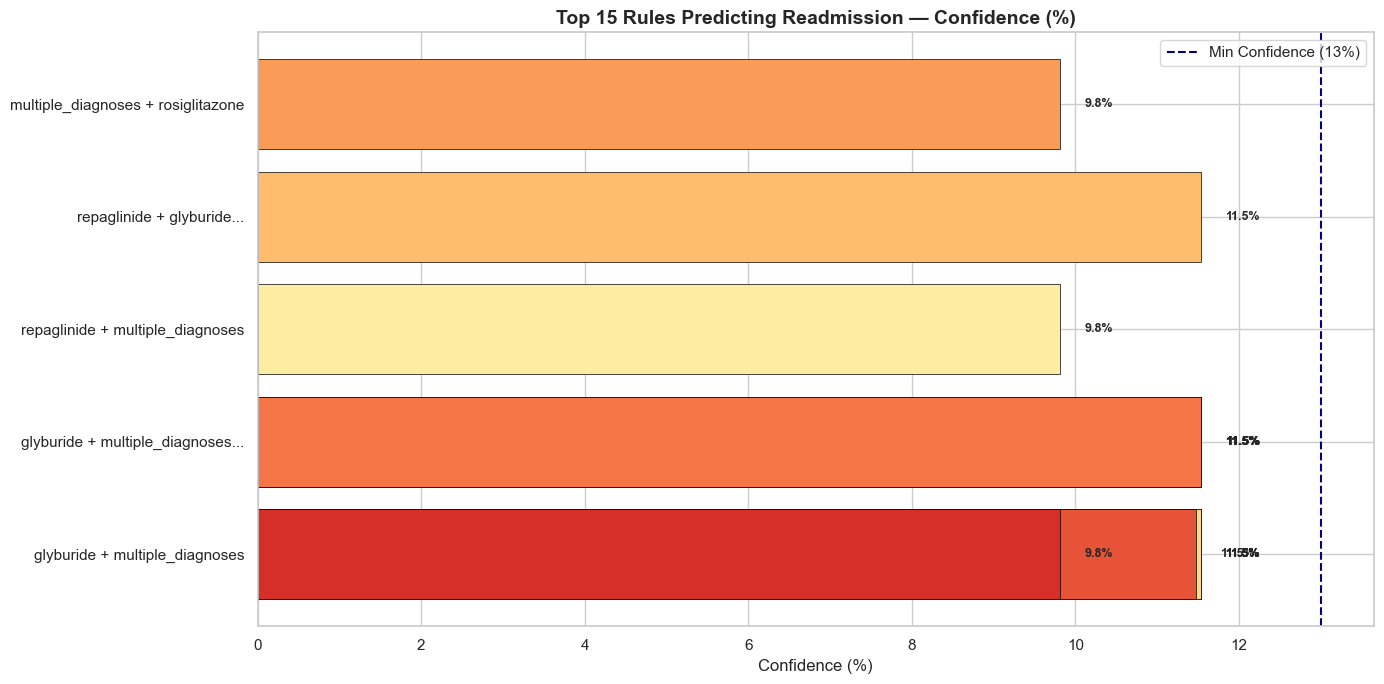

 Saved: ../outputImg/chart2_top_rules_confidence.png


In [13]:
top_rules = readmit_rules.head(15).copy()
top_rules['rule_label'] = top_rules['antecedents'].apply(
    lambda x: ' + '.join(list(x)[:2]) + ('...' if len(x) > 2 else '')
)

fig, ax = plt.subplots(figsize=(14, 7))
colors_conf = cm.RdYlGn_r(np.linspace(0.1, 0.9, len(top_rules)))
bars = ax.barh(top_rules['rule_label'][::-1],
               top_rules['confidence'][::-1] * 100,
               color=colors_conf, edgecolor='black', linewidth=0.5)

ax.set_title('Top 15 Rules Predicting Readmission — Confidence (%)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Confidence (%)')
ax.axvline(x=MIN_CONFIDENCE*100, color='navy', linestyle='--',
           linewidth=1.5, label=f'Min Confidence ({MIN_CONFIDENCE*100:.0f}%)')
ax.legend(fontsize=11)
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.3, bar.get_y() + bar.get_height()/2,
            f'{w:.1f}%', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputImg/chart42_top_rules_confidence.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: ../outputImg/chart2_top_rules_confidence.png')

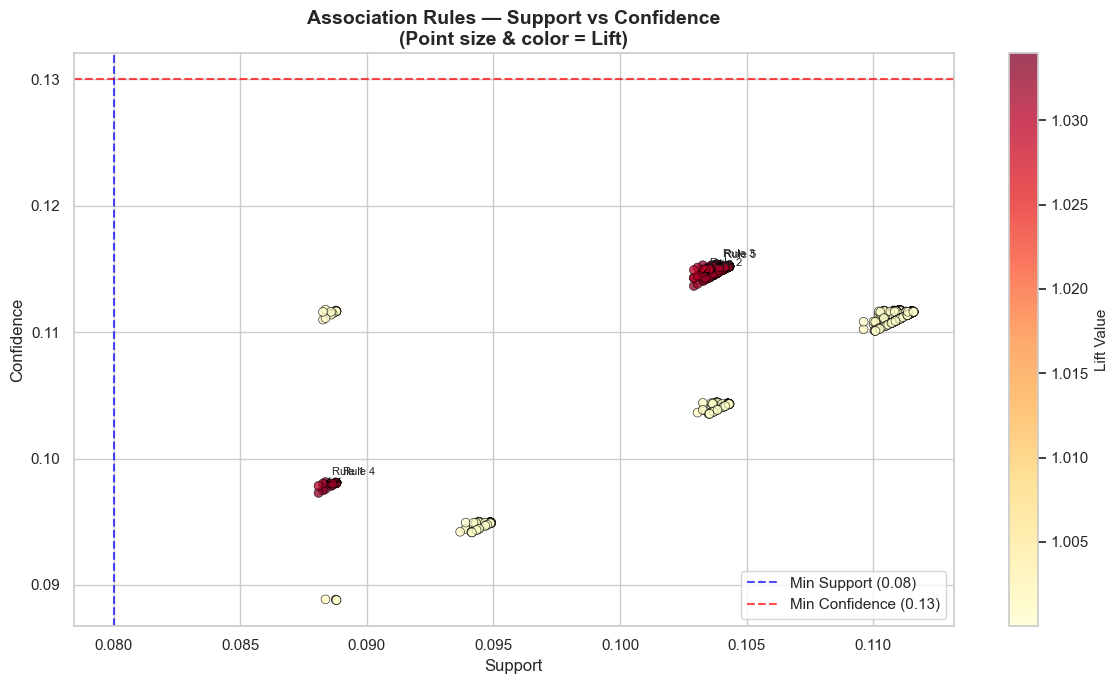

 Saved: ../outputImg/chart43_support_confidence_scatter.png


In [14]:
# ----- CHART 3: Scatter Plot — Support vs Confidence (sized by Lift) -----
fig, ax = plt.subplots(figsize=(12, 7))

scatter = ax.scatter(
    readmit_rules['support'],
    readmit_rules['confidence'],
    c=readmit_rules['lift'],
    s=readmit_rules['lift'] * 40,
    cmap='YlOrRd',
    alpha=0.75,
    edgecolors='black',
    linewidth=0.5
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Lift Value', fontsize=11)

ax.axvline(x=MIN_SUPPORT, color='blue', linestyle='--', linewidth=1.5,
           alpha=0.7, label=f'Min Support ({MIN_SUPPORT})')
ax.axhline(y=MIN_CONFIDENCE, color='red', linestyle='--', linewidth=1.5,
           alpha=0.7, label=f'Min Confidence ({MIN_CONFIDENCE})')

# Annotate top 5 rules by lift
for i, row in readmit_rules.head(5).iterrows():
    label = ' + '.join(list(row['antecedents'])[:1])
    ax.annotate(f'Rule {i+1}', (row['support'], row['confidence']),
                fontsize=8, xytext=(5, 5), textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color='black', lw=0.8))

ax.set_title('Association Rules — Support vs Confidence\n(Point size & color = Lift)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Support', fontsize=12)
ax.set_ylabel('Confidence', fontsize=12)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('../outputImg/chart43_support_confidence_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: ../outputImg/chart43_support_confidence_scatter.png')

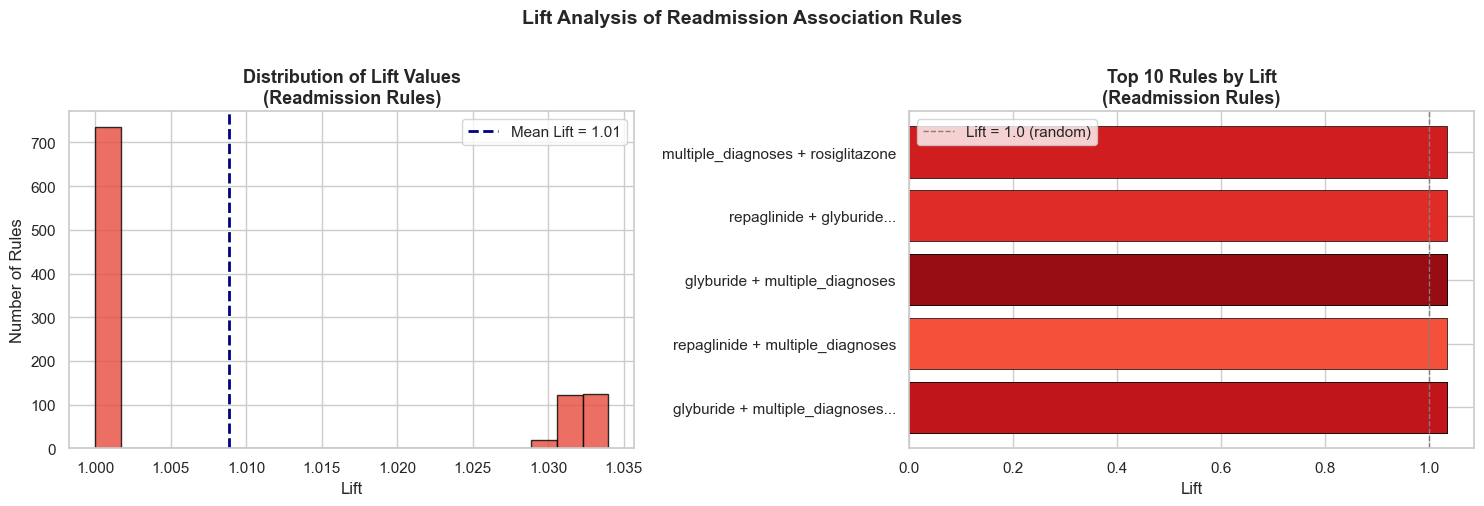

Saved: ../outputImg/chart44_lift_analysis.png


In [15]:
# ----- CHART 4: Lift Distribution of All Readmission Rules -----
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram of lift values
axes[0].hist(readmit_rules['lift'], bins=20, color='#e74c3c',
             edgecolor='black', alpha=0.8)
axes[0].axvline(readmit_rules['lift'].mean(), color='navy',
                linestyle='--', linewidth=2,
                label=f'Mean Lift = {readmit_rules["lift"].mean():.2f}')
axes[0].set_title('Distribution of Lift Values\n(Readmission Rules)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Lift')
axes[0].set_ylabel('Number of Rules')
axes[0].legend()

# Top 10 rules by lift — horizontal bar
top10 = readmit_rules.nlargest(10, 'lift')
top10['short_label'] = top10['antecedents'].apply(
    lambda x: ' + '.join(list(x)[:2]) + ('...' if len(x) > 2 else '')
)
lift_colors = cm.Reds(np.linspace(0.4, 0.9, len(top10)))
axes[1].barh(top10['short_label'][::-1], top10['lift'][::-1],
             color=lift_colors, edgecolor='black', linewidth=0.5)
axes[1].set_title('Top 10 Rules by Lift\n(Readmission Rules)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Lift')
axes[1].axvline(1.0, color='gray', linestyle='--', linewidth=1,
                label='Lift = 1.0 (random)')
axes[1].legend()

plt.suptitle('Lift Analysis of Readmission Association Rules',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputImg/chart44_lift_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../outputImg/chart44_lift_analysis.png')

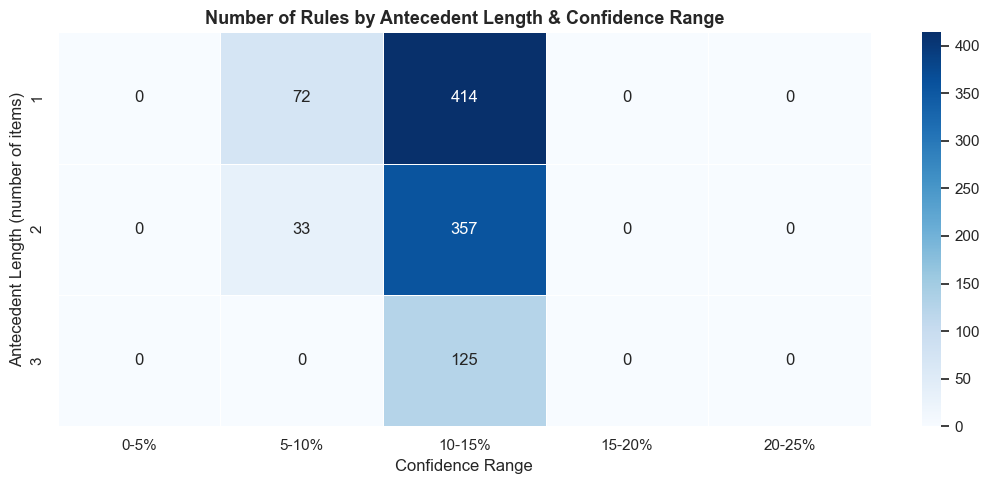

 Saved: ../outputImg/chart45_rule_heatmap.png


In [23]:
# ----- CHART 5: Heatmap — Confidence by Rule Length -----
readmit_rules['antecedent_length'] = readmit_rules['antecedents'].apply(len)
readmit_rules['confidence_bin'] = pd.cut(readmit_rules['confidence'],
                                          bins=[0, 0.05, 0.1, 0.15, 0.2, 0.25],
                                          labels=['0-5%','5-10%','10-15%','15-20%','20-25%'])

heatmap_data = readmit_rules.groupby(
    ['antecedent_length', 'confidence_bin']
).size().unstack(fill_value=0)

if not heatmap_data.empty:
    fig, ax = plt.subplots(figsize=(11, 5))
    sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='Blues',
                linewidths=0.5, ax=ax, annot_kws={'size': 12})
    ax.set_title('Number of Rules by Antecedent Length & Confidence Range',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Confidence Range')
    ax.set_ylabel('Antecedent Length (number of items)')
    plt.tight_layout()
    plt.savefig('../outputImg/chart45_rule_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(' Saved: ../outputImg/chart45_rule_heatmap.png')
else:
    print('  Not enough rule variation for heatmap — try lowering MIN_SUPPORT')

In [24]:
# Analyze which rules are most prevalent in each patient cluster
print('=' * 65)
print('🔍 RULE ANALYSIS BY PATIENT CLUSTER')
print('=' * 65)

for cluster_id in sorted(df['cluster'].unique()):
    cluster_df = df[df['cluster'] == cluster_id]
    cluster_readmit_rate = cluster_df['readmitted_30'].mean() * 100
    cluster_size = len(cluster_df)

    print(f'\n Cluster {cluster_id} — {cluster_size:,} patients | '
          f'Readmission Rate: {cluster_readmit_rate:.1f}%')

    # Build transactions for this cluster
    cluster_trans = df_transactions.loc[cluster_df.index]

    # Item frequencies within this cluster
    cluster_item_freq = cluster_trans.mean().sort_values(ascending=False)
    top5 = cluster_item_freq.head(5)
    print(f'  Top 5 items in this cluster:')
    for item, freq in top5.items():
        print(f'    • {item}: {freq*100:.1f}% of patients')

🔍 RULE ANALYSIS BY PATIENT CLUSTER

 Cluster 0 — 3,824 patients | Readmission Rate: 12.1%
  Top 5 items in this cluster:
    • nateglinide: 100.0% of patients
    • chlorpropamide: 100.0% of patients
    • acarbose: 100.0% of patients
    • glyburide-metformin: 100.0% of patients
    • repaglinide: 100.0% of patients

 Cluster 1 — 4,943 patients | Readmission Rate: 27.6%
  Top 5 items in this cluster:
    • nateglinide: 100.0% of patients
    • chlorpropamide: 100.0% of patients
    • repaglinide: 100.0% of patients
    • glyburide-metformin: 100.0% of patients
    • rosiglitazone: 100.0% of patients

 Cluster 2 — 28,261 patients | Readmission Rate: 7.7%
  Top 5 items in this cluster:
    • acarbose: 100.0% of patients
    • nateglinide: 100.0% of patients
    • chlorpropamide: 100.0% of patients
    • repaglinide: 100.0% of patients
    • glyburide-metformin: 100.0% of patients

 Cluster 3 — 43,531 patients | Readmission Rate: 10.9%
  Top 5 items in this cluster:
    • chlorpropamide:

In [27]:
print('=' * 70)
print('📋 ASSOCIATION RULE MINING — SUMMARY')
print('=' * 70)
print(f'\n Dataset: {len(df_transactions):,} patient transactions')
print(f'🛒 Total items in transaction set: {df_transactions.shape[1]}')
print(f'\n  Parameters:')
print(f'   Min Support:    {MIN_SUPPORT} ({MIN_SUPPORT*100:.0f}% of patients)')
print(f'   Min Confidence: {MIN_CONFIDENCE}')
print(f'   Min Lift:       {MIN_LIFT}')
print(f'\n Results:')
print(f'   Frequent itemsets found:        {len(frequent_itemsets):,}')
print(f'   Total association rules:        {len(rules):,}')
print(f'   Rules predicting readmission:   {len(readmit_rules):,}')
print(f'\n Top 3 Strongest Rules (by Lift):')
for i, row in readmit_rules.head(3).iterrows():
    ant = ', '.join(list(row['antecedents']))
    con = ', '.join(list(row['consequents']))
    print(f'\n  Rule {i+1}: IF [{ant}]')
    print(f'           THEN [{con}]')
    print(f'           Confidence: {row["confidence"]*100:.1f}% | Lift: {row["lift"]:.2f} | Support: {row["support"]*100:.1f}%')
print('\n' + '=' * 70)

📋 ASSOCIATION RULE MINING — SUMMARY

 Dataset: 101,766 patient transactions
🛒 Total items in transaction set: 29

  Parameters:
   Min Support:    0.08 (8% of patients)
   Min Confidence: 0.13
   Min Lift:       1.3

 Results:
   Frequent itemsets found:        6,680
   Total association rules:        36,150
   Rules predicting readmission:   1,001

 Top 3 Strongest Rules (by Lift):

  Rule 1: IF [glyburide, multiple_diagnoses]
           THEN [insulin, readmitted_30d]
           Confidence: 9.8% | Lift: 1.03 | Support: 8.8%

  Rule 2: IF [glyburide, multiple_diagnoses]
           THEN [metformin, readmitted_30d]
           Confidence: 11.5% | Lift: 1.03 | Support: 10.3%

  Rule 3: IF [glyburide, multiple_diagnoses, rosiglitazone]
           THEN [readmitted_30d]
           Confidence: 11.5% | Lift: 1.03 | Support: 10.4%



In [26]:
rules_to_save = rules.copy()
rules_to_save['antecedents'] = rules_to_save['antecedents'].apply(
    lambda x: ', '.join(sorted(list(x)))
)
rules_to_save['consequents'] = rules_to_save['consequents'].apply(
    lambda x: ', '.join(sorted(list(x)))
)
# Drop non-serializable columns if present
for col in ['antecedent_length', 'confidence_bin']:
    if col in rules_to_save.columns:
        rules_to_save.drop(columns=[col], inplace=True)

# Save all rules
rules_to_save.to_csv('../data/association_rules.csv', index=False)

# Save readmission-specific rules separately (Flask API uses this)
readmit_to_save = readmit_rules.copy()
readmit_to_save['antecedents'] = readmit_to_save['antecedents'].apply(
    lambda x: ', '.join(sorted(list(x)))
)
readmit_to_save['consequents'] = readmit_to_save['consequents'].apply(
    lambda x: ', '.join(sorted(list(x)))
)
for col in ['antecedent_length', 'confidence_bin']:
    if col in readmit_to_save.columns:
        readmit_to_save.drop(columns=[col], inplace=True)

readmit_to_save.to_csv('../data/readmission_rules.csv', index=False)

# Save transaction column names for Flask API
joblib.dump(list(df_transactions.columns), '../models/transaction_columns.pkl')

['../models/transaction_columns.pkl']